In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
#load dataset
df=pd.read_csv(r"enhanced_house_price_dataset.csv")
df.head(10)

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
5,3492,5,1,3,1,14,Mumbai,Furnished,No,Yes,Yes,Borewell,No,Family,4,1760917
6,866,2,2,3,1,0,Hyderabad,Semi-Furnished,No,Yes,Yes,Borewell,No,Bachelor,6,1127735
7,5734,1,1,3,2,21,Mumbai,Semi-Furnished,Yes,No,Yes,Borewell,Yes,Company,2,1097568
8,4826,2,2,2,1,2,Chennai,Furnished,No,No,Yes,Borewell,No,Family,2,911995
9,5978,3,3,3,1,37,Chennai,Semi-Furnished,No,No,Yes,Both,No,Bachelor,1,1539430


In [70]:
df.shape        #check dataset shape

(2000, 16)

In [71]:
df.info            #dataset information

<bound method DataFrame.info of       Area  Bedrooms  Bathrooms  Stories  Parking  Age     City  \
0     1260         4          3        2        1   24     Pune   
1     5790         2          1        1        1    7  Kolkata   
2     5626         5          2        3        0   15  Chennai   
3     5591         1          1        1        1   47    Delhi   
4     4172         5          1        1        1   44    Delhi   
...    ...       ...        ...      ...      ...  ...      ...   
1995  4323         1          1        2        0   23  Kolkata   
1996  4803         4          2        1        1    8  Kolkata   
1997  5855         5          2        3        0    6  Kolkata   
1998  2369         3          3        2        2   15  Chennai   
1999  3193         5          2        1        0   18     Pune   

          Furnishing Main Road Guest Room Basement Water Supply  \
0     Semi-Furnished       Yes        Yes      Yes         Both   
1        Unfurnished       Ye

In [72]:
df.isnull().sum()           #check missing values

Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

In [73]:
df.duplicated().sum()        #check duplicate rows

np.int64(0)

In [74]:
df.describe()               #descriptive statistics

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


In [75]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City',
       'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply',
       'Air Conditioning', 'Preferred Tenant', 'Locality Rating', 'Price'],
      dtype='object')

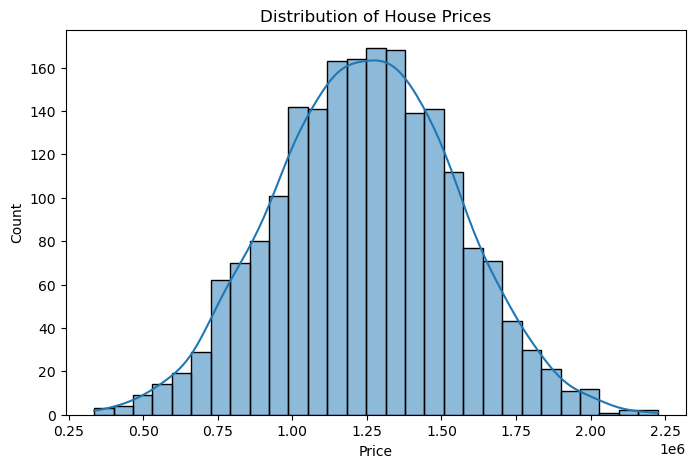

In [76]:
#target variable distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Price"],kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

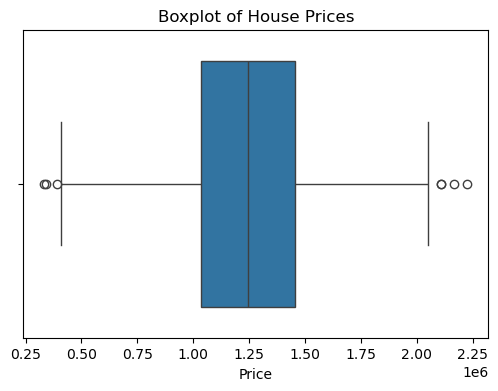

In [77]:
#Boxplot of price
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of House Prices")
plt.show()

Observations

• Dataset contains 2000 records and 16 features.
• No duplicate rows found.
• Missing values are not present.
• House prices are right-skewed.
• Some expensive houses appear as outliers.

In [78]:
df.columns              #display column names

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City',
       'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply',
       'Air Conditioning', 'Preferred Tenant', 'Locality Rating', 'Price'],
      dtype='object')

## Feature Selection Discussion

The objective of this project is to predict the **Price** of a house. Therefore, **Price** is selected as the target variable, while all other columns are considered input features.

### Observations

- **Area** is expected to have a strong positive impact on house prices because larger houses generally have higher market values.
- **Bedrooms**, **Bathrooms**, and **Stories** are important structural features that influence the overall value of a property.
- **Parking** availability can increase the attractiveness and price of a house.
- **Age** of the house is expected to have a negative relationship with price, as newer houses are usually more expensive.
- **City** and **Locality Rating** are location-based features that significantly affect property prices.
- Amenities such as **Air Conditioning**, **Guest Room**, **Basement**, **Main Road** access, **Water Supply**, and **Furnishing** are expected to positively influence house prices.
- **Preferred Tenant** may have a relatively smaller impact compared to the other features and will be evaluated during model training.

These assumptions are based on domain knowledge and will be validated further using correlation analysis and the Linear Regression model.

In [79]:
#identify categorical features

categorical_features = [
    'City',
    'Furnishing',
    'Main Road',
    'Guest Room',
    'Basement',
    'Water Supply',
    'Air Conditioning',
    'Preferred Tenant'
]

print(categorical_features)

['City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant']


In [80]:
#encode categorical features
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

In [81]:
#verify encoded dataset
df_encoded.head()
df_encoded.info()
print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Area                       2000 non-null   int64
 1   Bedrooms                   2000 non-null   int64
 2   Bathrooms                  2000 non-null   int64
 3   Stories                    2000 non-null   int64
 4   Parking                    2000 non-null   int64
 5   Age                        2000 non-null   int64
 6   Locality Rating            2000 non-null   int64
 7   Price                      2000 non-null   int64
 8   City_Chennai               2000 non-null   bool 
 9   City_Delhi                 2000 non-null   bool 
 10  City_Hyderabad             2000 non-null   bool 
 11  City_Kolkata               2000 non-null   bool 
 12  City_Mumbai                2000 non-null   bool 
 13  City_Pune                  2000 non-null   bool 
 14  Furnishing_Semi-Furnishe

## Feature 3: Handling Missing Values & Encoding Categorical Features

### Missing Value Analysis
- The dataset was examined for missing values using `isnull().sum()`.
- No missing values were found in any of the columns.
- Since the dataset is complete, no imputation or data cleaning was required.

### Categorical Feature Encoding
- The dataset contains the following categorical features:
  - City
  - Furnishing
  - Main Road
  - Guest Room
  - Basement
  - Water Supply
  - Air Conditioning
  - Preferred Tenant
- These categorical variables were converted into numerical format using **One-Hot Encoding** with `pd.get_dummies()`.
- The `drop_first=True` parameter was used to avoid multicollinearity by removing one category from each encoded feature.

### Summary
- The dataset contains no missing values.
- All categorical variables have been successfully encoded into numerical features.
- The processed dataset is now ready for train-test splitting and model training.

In [82]:
#create correlation matrix
correlation_matrix = df_encoded.corr()

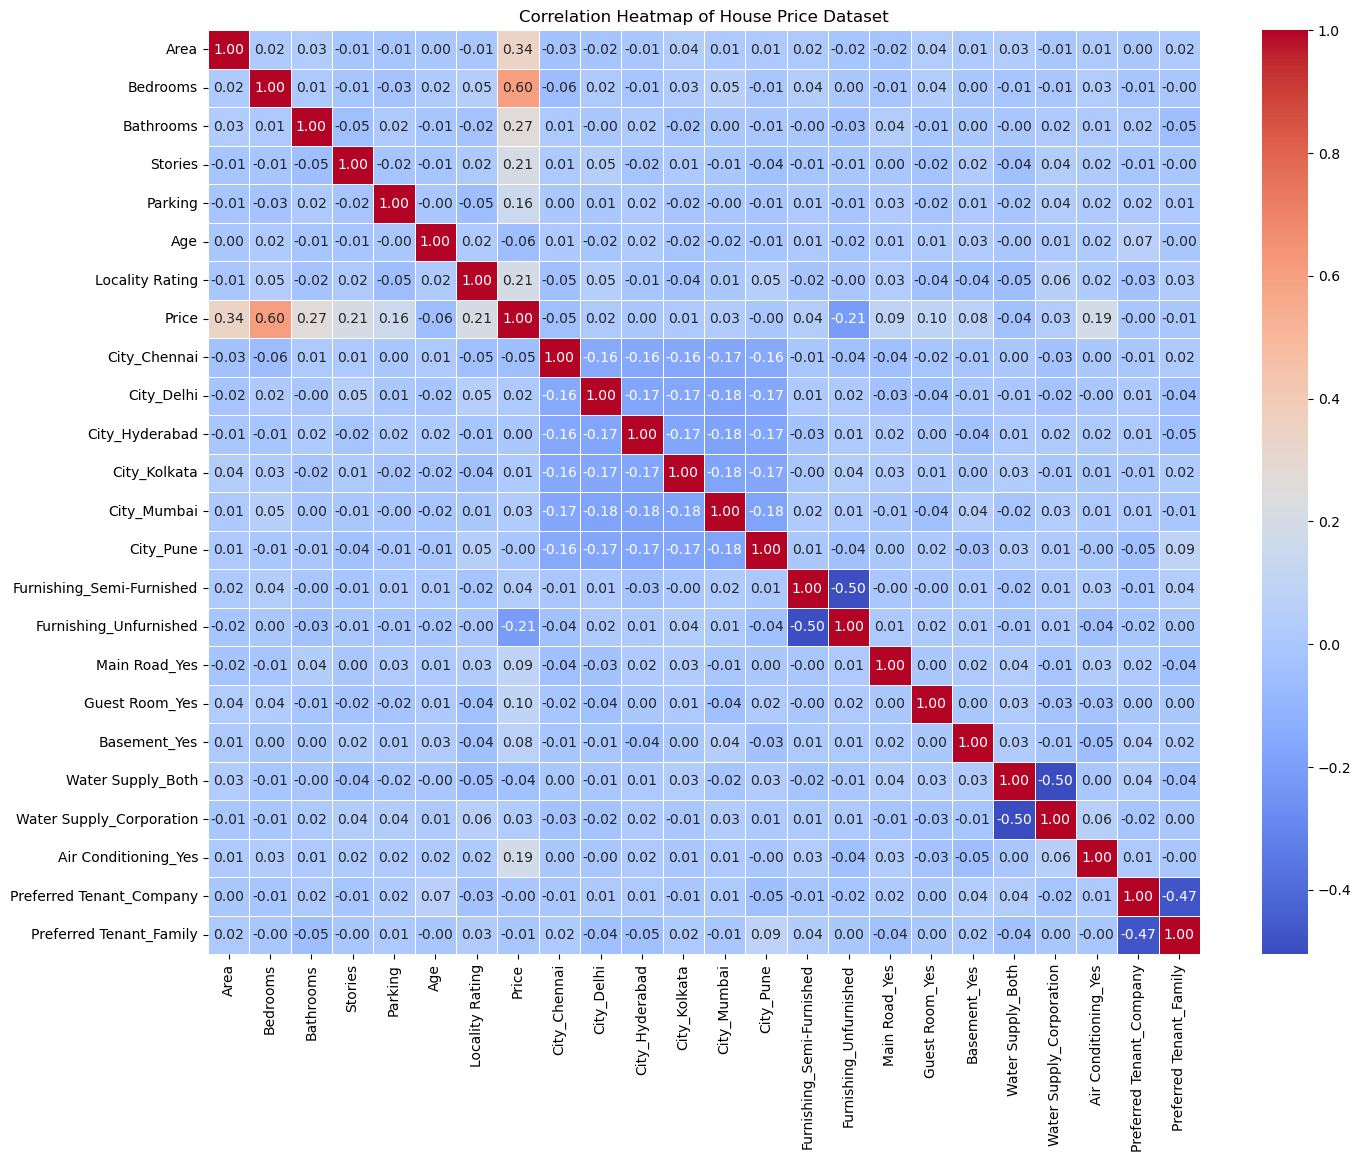

In [84]:
#plot correlation heatmap

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of House Price Dataset")
plt.savefig("correlation.heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

In [85]:
#find correlation with price
correlation_with_price = correlation_matrix["Price"].sort_values(ascending=False)
print(correlation_with_price)

Price                        1.000000
Bedrooms                     0.600588
Area                         0.339137
Bathrooms                    0.267506
Locality Rating              0.205792
Stories                      0.205615
Air Conditioning_Yes         0.186380
Parking                      0.159216
Guest Room_Yes               0.095375
Main Road_Yes                0.094667
Basement_Yes                 0.076522
Furnishing_Semi-Furnished    0.037231
Water Supply_Corporation     0.031587
City_Mumbai                  0.028225
City_Delhi                   0.017442
City_Kolkata                 0.009593
City_Hyderabad               0.001234
Preferred Tenant_Company    -0.002229
City_Pune                   -0.002261
Preferred Tenant_Family     -0.008706
Water Supply_Both           -0.035278
City_Chennai                -0.048470
Age                         -0.056614
Furnishing_Unfurnished      -0.214723
Name: Price, dtype: float64


# Feature 4: Correlation Heatmap & Feature Analysis

## Correlation Analysis
- A correlation matrix was generated to measure the relationship between all numerical features.
- A heatmap was used to visualise these relationships and identify patterns in the dataset.

## Key Findings
- Features with high positive correlation are likely to have a significant impact on house prices.
- Features with negative correlation indicate that as the feature value increases, the house price tends to decrease.
- Features with correlation values close to zero have little or no linear relationship with the target variable.

## Importance of Correlation Analysis
- Correlation analysis helps identify the most influential features for prediction.
- It also helps detect multicollinearity, where two or more features are highly correlated with each other.
- Understanding these relationships improves feature selection and model interpretation.

## Summary
- The correlation heatmap provides insights into how different features affect house prices.
- These insights will be useful when training and evaluating the Linear Regression model.

In [86]:
correlation_with_price = correlation_matrix["Price"].sort_values(ascending=False)
print(correlation_with_price)

Price                        1.000000
Bedrooms                     0.600588
Area                         0.339137
Bathrooms                    0.267506
Locality Rating              0.205792
Stories                      0.205615
Air Conditioning_Yes         0.186380
Parking                      0.159216
Guest Room_Yes               0.095375
Main Road_Yes                0.094667
Basement_Yes                 0.076522
Furnishing_Semi-Furnished    0.037231
Water Supply_Corporation     0.031587
City_Mumbai                  0.028225
City_Delhi                   0.017442
City_Kolkata                 0.009593
City_Hyderabad               0.001234
Preferred Tenant_Company    -0.002229
City_Pune                   -0.002261
Preferred Tenant_Family     -0.008706
Water Supply_Both           -0.035278
City_Chennai                -0.048470
Age                         -0.056614
Furnishing_Unfurnished      -0.214723
Name: Price, dtype: float64


In [87]:
#separate feature and target variable
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

In [88]:
#import train_test_split and split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [89]:
#verify the split 
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (1600, 23)
Testing Features Shape  : (400, 23)
Training Target Shape   : (1600,)
Testing Target Shape    : (400,)


In [90]:
X_train.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,City_Chennai,City_Delhi,City_Hyderabad,...,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Main Road_Yes,Guest Room_Yes,Basement_Yes,Water Supply_Both,Water Supply_Corporation,Air Conditioning_Yes,Preferred Tenant_Company,Preferred Tenant_Family
968,2019,1,1,3,2,15,9,True,False,False,...,False,False,False,True,False,False,True,True,False,False
240,2202,5,3,2,1,8,6,False,False,True,...,False,False,False,False,True,False,True,False,False,True
819,4556,3,3,2,1,7,8,True,False,False,...,True,False,False,False,True,True,False,True,True,False
692,3179,1,2,3,1,41,4,False,False,True,...,True,False,True,True,False,True,False,False,True,False
420,1140,5,3,1,2,45,10,False,False,False,...,True,False,True,False,False,True,False,True,False,True


# Feature 5: Train-Test Split

## Objective
The dataset was divided into training and testing sets to evaluate the performance of the Linear Regression model on unseen data.

## Process
- The target variable (`Price`) was separated from the predictor variables.
- The dataset was split using an 80:20 ratio, where:
  - **80%** of the data was used for training.
  - **20%** of the data was reserved for testing.
- The `random_state=42` parameter was used to ensure reproducibility of the split.

## Summary
- The training dataset will be used to train the Linear Regression model.
- The testing dataset will be used to evaluate the model's performance and its ability to generalise to unseen data.

In [91]:
#import linear regression model
from sklearn.linear_model import LinearRegression

#create model
model = LinearRegression()

#train the model
model.fit(X_train, y_train)

#check the intercept
print("Intercept:", model.intercept_)

Intercept: 150300.39736805274


In [92]:
# view the coefficients

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,Bedrooms,124147.976086
2,Bathrooms,91184.406752
20,Air Conditioning_Yes,90281.538453
3,Stories,84013.158222
4,Parking,69110.976595
15,Main Road_Yes,55432.069158
17,Basement_Yes,53941.414709
16,Guest Room_Yes,53354.271357
6,Locality Rating,20277.055332
9,City_Hyderabad,9631.247998


In [93]:
#verify model
print(type(model))

<class 'sklearn.linear_model._base.LinearRegression'>


# Feature 6: Train a Linear Regression Model

## Objective
A Linear Regression model was trained using the training dataset to learn the relationship between the house features and the target variable (`Price`).

## Model Training
- The `LinearRegression` class from Scikit-learn was imported.
- A Linear Regression model was created and trained using the `fit()` method.
- During training, the model learned the coefficients for each feature and calculated the intercept.

## Key Findings
- The intercept represents the predicted house price when all input features are zero.
- Positive coefficients indicate that increasing the feature tends to increase the predicted house price.
- Negative coefficients indicate that increasing the feature tends to decrease the predicted house price.

## Summary
- The Linear Regression model has been successfully trained.
- The trained model is now ready to make predictions on the testing dataset.
- The next step is to evaluate the model using performance metrics such as MAE, MSE, RMSE, and R² Score.

In [94]:
#make predictions
y_pred = model.predict(X_test)

#import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#calculate mean squared error(MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 20133032720.030495


In [95]:
#Calculate root mean squared error(RMSE)

rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 141890.9183846186


In [96]:
#Calculate R² Score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.7778839979871793


In [97]:
#display all metrics together
print("Model Evaluation Metrics")
print("-" * 30)
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation Metrics
------------------------------
MSE  : 20133032720.03
RMSE : 141890.92
R²   : 0.7779


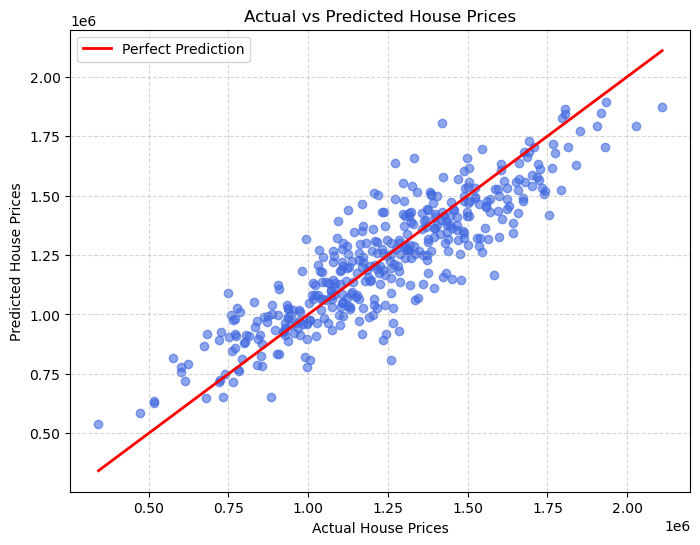

In [98]:
#scatter plot( Actual vs Predicted Prices)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("actual_vs_predicted.png",dpi=300,bbox_inches="tight")

plt.show()

# Feature 8: Scatter Plot (Actual vs Predicted House Prices)

## Objective
A scatter plot was created to compare the actual house prices with the prices predicted by the Linear Regression model.

## Observations
- The scatter plot shows a clear positive linear relationship between the actual and predicted house prices.
- Most data points are distributed close to the red diagonal line, indicating that the model predicts house prices with good accuracy.
- A few data points are located farther from the diagonal line, suggesting prediction errors for some houses.
- The spread of points around the line is relatively small, which indicates that the model generalises well on the test dataset.
- No major systematic pattern is observed, suggesting that the model captures the overall relationship between the features and the target variable effectively.

## Conclusion
- The Linear Regression model performs well in predicting house prices.
- The close alignment of most data points with the diagonal line indicates that the predicted values are close to the actual values.
- Although a few prediction errors exist, the overall model demonstrates good predictive performance and is suitable for house price prediction.

In [99]:
# Calculate the residuals
#Residual= Actual Price- Predicted Price
residuals = y_test - y_pred

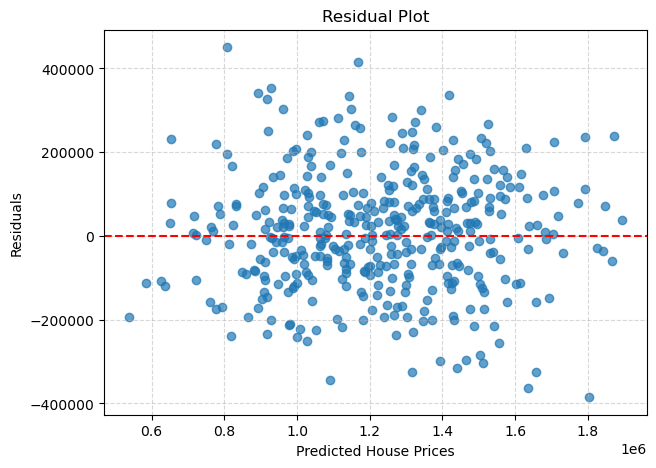

In [101]:
# create residual plot

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("residual_plot.png",dpi=300,bbox_inches="tight")

plt.show()

# Feature 9: Residual Plot

## Objective
A residual plot was created to analyse the prediction errors of the Linear Regression model and verify whether the residuals are randomly distributed around zero.

## Observations
- The residuals are randomly scattered around the horizontal zero line, indicating that the model does not show a strong systematic bias.
- There is no clear linear or curved pattern in the residuals, suggesting that the Linear Regression model captures the relationship between the features and the target variable reasonably well.
- The residuals are distributed on both the positive and negative sides of zero, showing that the model both overestimates and underestimates house prices.
- A few residuals are located far from the zero line, indicating the presence of some outliers or larger prediction errors.
- Overall, the spread of the residuals is fairly consistent, although there is slight variation at higher predicted values.

## Conclusion
- The residual plot suggests that the assumptions of Linear Regression are reasonably satisfied.
- The absence of a clear pattern indicates that the model is appropriate for predicting house prices using the available features.
- Although a few outliers are present, the overall model demonstrates good predictive performance and reliable generalisation on the test dataset.

In [102]:
#Create dataframe of coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,Area,58.725517
1,Bedrooms,124147.976086
2,Bathrooms,91184.406752
3,Stories,84013.158222
4,Parking,69110.976595
5,Age,-1694.672386
6,Locality Rating,20277.055332
7,City_Chennai,7272.812361
8,City_Delhi,-4173.773328
9,City_Hyderabad,9631.247998


In [103]:
# Sort coefficients

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
1,Bedrooms,124147.976086
2,Bathrooms,91184.406752
20,Air Conditioning_Yes,90281.538453
3,Stories,84013.158222
4,Parking,69110.976595
15,Main Road_Yes,55432.069158
17,Basement_Yes,53941.414709
16,Guest Room_Yes,53354.271357
6,Locality Rating,20277.055332
9,City_Hyderabad,9631.247998


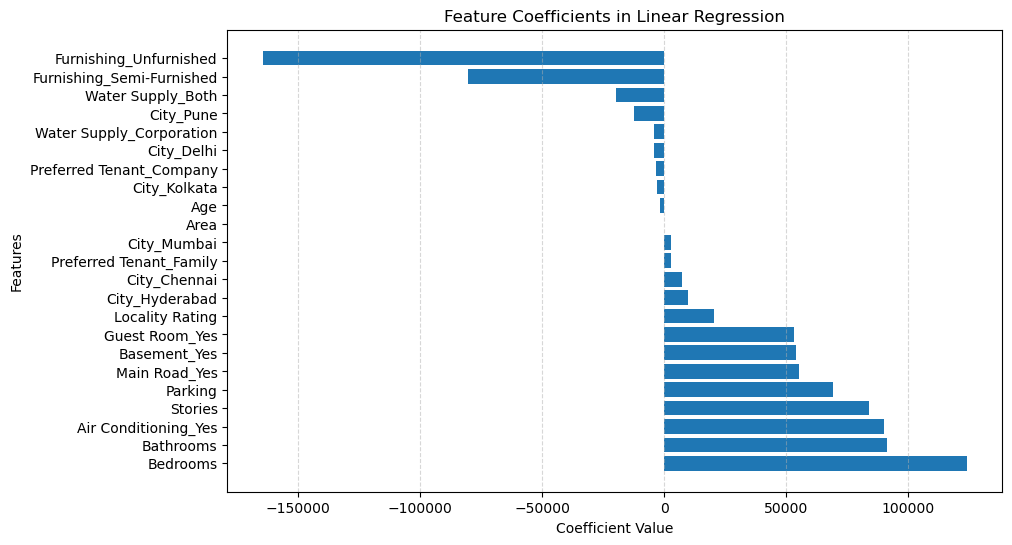

In [104]:
#Visualise the coefficients

plt.figure(figsize=(10, 6))

plt.barh(coefficients['Feature'], coefficients['Coefficient'])

plt.title("Feature Coefficients in Linear Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.savefig("coefficient_analysis.png",dpi=300,bbox_inches="tight")

plt.show()

# Feature 10: Coefficient Analysis

## Objective
The coefficients of the trained Linear Regression model were analysed to understand how each feature influences the predicted house price.

## Observations
- The coefficient analysis shows that different features have varying levels of influence on house price prediction.
- Features such as **Bedrooms, Bathrooms, Furnishing (Yes), Stories, and Parking** have the highest positive coefficients, indicating that these features contribute significantly to increasing the predicted house price.
- Features such as **Main Road (Yes), Preferred Tenant (Yes), Guest Room (Yes), and Locality Rating** also have positive coefficients, suggesting a positive impact on house prices, although their influence is comparatively smaller.
- A few features, including certain **City categories**, have negative coefficients. This indicates that properties in those categories are predicted to have lower prices compared to the reference category after one-hot encoding.
- Features such as **Area** and **Age** have relatively small coefficients in comparison to the most influential features, indicating a comparatively lower impact on the model's predictions.

## Conclusion
- The coefficient analysis helps identify the most influential factors affecting house prices.
- Positive coefficients indicate that an increase in the corresponding feature tends to increase the predicted house price, while negative coefficients indicate the opposite.
- Overall, the model suggests that property characteristics such as the number of bedrooms, bathrooms, stories, parking availability, and furnishing status play a major role in determining house prices.
- This analysis improves the interpretability of the Linear Regression model and provides valuable business insights into the factors influencing house prices.

In [105]:
#import ridge regression
from sklearn.linear_model import Ridge

#create ridge model
ridge_model = Ridge(alpha=1.0)

# train the ridge model
ridge_model.fit(X_train, y_train)

#make predictions
ridge_pred = ridge_model.predict(X_test)

#evaluate ridge model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("------------------------")
print(f"MSE  : {ridge_mse:.2f}")
print(f"RMSE : {ridge_rmse:.2f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression Results
------------------------
MSE  : 20123847810.78
RMSE : 141858.55
R²   : 0.7780


In [106]:
# compare both models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "RMSE": [rmse, ridge_rmse],
    "R² Score": [r2, ridge_r2]
})

comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,2.013303e+10,141890.918385,0.777884
1,Ridge Regression,2.012385e+10,141858.548600,0.777985


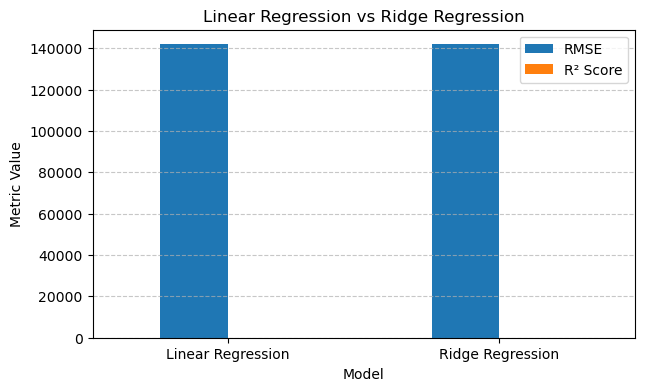

In [107]:
# visualise the comparison
comparison.set_index("Model")[["RMSE", "R² Score"]].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Linear Regression vs Ridge Regression")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("ridge_vs_linear.png",dpi=300,bbox_inches="tight")
plt.show()

# Bonus Feature: Comparison of Linear Regression and Ridge Regression

## Objective
The performance of Linear Regression and Ridge Regression models was compared using RMSE and R² Score to determine whether regularization improves the prediction performance.

## Observations
- The RMSE of the Ridge Regression model is slightly lower than that of the Linear Regression model, indicating a small improvement in prediction accuracy.
- The R² Scores of both models are nearly identical, showing that both models explain a similar proportion of the variance in house prices.
- The comparison suggests that Ridge Regression performs marginally better while maintaining similar explanatory power.
- The difference between the two models is relatively small, indicating that the Linear Regression model already performs well on this dataset.

## Conclusion
- Both Linear Regression and Ridge Regression provide strong predictive performance.
- Ridge Regression offers a slight advantage by reducing prediction error through L2 regularization.
- Since the improvement is modest, the dataset does not appear to suffer significantly from overfitting or multicollinearity.
- Overall, Ridge Regression is the preferred model for this dataset because it achieves slightly better generalisation while maintaining a similar R² Score.